# 09 - Model Monitoring

**Objectif** : Démontrer le monitoring des modèles ML en production.

Ce notebook montre :
1. Détection de drift des données (PSI, test KS)
2. Détection de drift des prédictions
3. Monitoring des performances
4. Alertes automatiques

**Compétence validée** : C13 (Monitoring ML)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modules de monitoring
from mlops.monitoring import (
    calculate_psi,
    detect_data_drift,
    detect_prediction_drift,
    check_model_performance,
    ModelMonitor,
    DriftReport,
    PerformanceReport,
    generate_monitoring_summary,
)
from mlops.config import PERFORMANCE_THRESHOLDS

# Seed pour reproductibilité
np.random.seed(42)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement des données

On charge les données de référence (training) et les données actuelles (production).

In [2]:
# Charger les données depuis Supabase
from datetime import datetime
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

from data.extractors.extract_yfinance import download_etf_prices, ETF_TICKERS
from ml.features import prepare_regime_features

load_dotenv()

# Charger prix ETF
prices = download_etf_prices(ETF_TICKERS, start_date="2010-01-01", end_date=datetime.now().strftime("%Y-%m-%d"))

# Charger macro depuis DB
DATABASE_URL = os.getenv("SUPABASE_DB_URL")
engine = create_engine(DATABASE_URL)

query_macro = """
SELECT date, vix, credit_spread_hy, yield_curve_10y2y
FROM macro_indicator
ORDER BY date
"""

macro_df = pd.read_sql(query_macro, engine, parse_dates=['date'])
macro_df = macro_df.set_index('date')

# Remplir les valeurs manquantes
if macro_df['credit_spread_hy'].isna().any():
    macro_df['credit_spread_hy'] = macro_df['credit_spread_hy'].ffill().bfill().fillna(4.5)

# Combiner
combined_df = prices.join(macro_df, how='inner')

# Préparer les features
regime_features = prepare_regime_features(combined_df)

# Séparer en référence (avant 2022) et actuel (2022+)
X_reference = regime_features[regime_features.index < '2022-01-01'].dropna()
X_current = regime_features[regime_features.index >= '2022-01-01'].dropna()

print(f"Données référence: {X_reference.shape}")
print(f"Données actuelles: {X_current.shape}")
print(f"\nFeatures: {list(X_reference.columns)}")

2026-05-15 21:03:01,045 - INFO - Téléchargement de 8 tickers: ['SPY', 'EFA', 'EEM', 'TLT', 'HYG', 'GLD', 'VNQ', 'SH']
2026-05-15 21:03:01,046 - INFO - Période: 2010-01-01 → 2026-05-15
[*********************100%***********************]  8 of 8 completed
2026-05-15 21:03:01,709 - INFO - Tickers téléchargés avec succès: ['SPY', 'EFA', 'EEM', 'TLT', 'HYG', 'GLD', 'VNQ', 'SH']
2026-05-15 21:03:01,709 - INFO - Nombre de lignes: 4116


Données référence: (3021, 5)
Données actuelles: (1095, 5)

Features: ['vix_zscore', 'credit_spread_zscore', 'yield_curve_10y2y', 'spy_return_20d', 'spy_volatility_20d']


## 2. Population Stability Index (PSI)

Le PSI mesure le changement de distribution entre deux populations :
- PSI < 0.1 : pas de changement significatif
- 0.1 ≤ PSI < 0.25 : changement modéré
- PSI ≥ 0.25 : changement significatif (drift)

In [3]:
# Calculer le PSI pour chaque feature
psi_values = {}
for col in X_reference.columns:
    psi = calculate_psi(X_reference[col].values, X_current[col].values)
    psi_values[col] = psi

# Afficher triés par PSI
psi_df = pd.DataFrame({
    'feature': psi_values.keys(),
    'psi': psi_values.values()
}).sort_values('psi', ascending=False)

print("PSI par feature:")
print(psi_df.to_string(index=False))

PSI par feature:
             feature      psi
   yield_curve_10y2y 5.485533
  spy_volatility_20d 0.305927
      spy_return_20d 0.092478
credit_spread_zscore 0.034137
          vix_zscore 0.027316


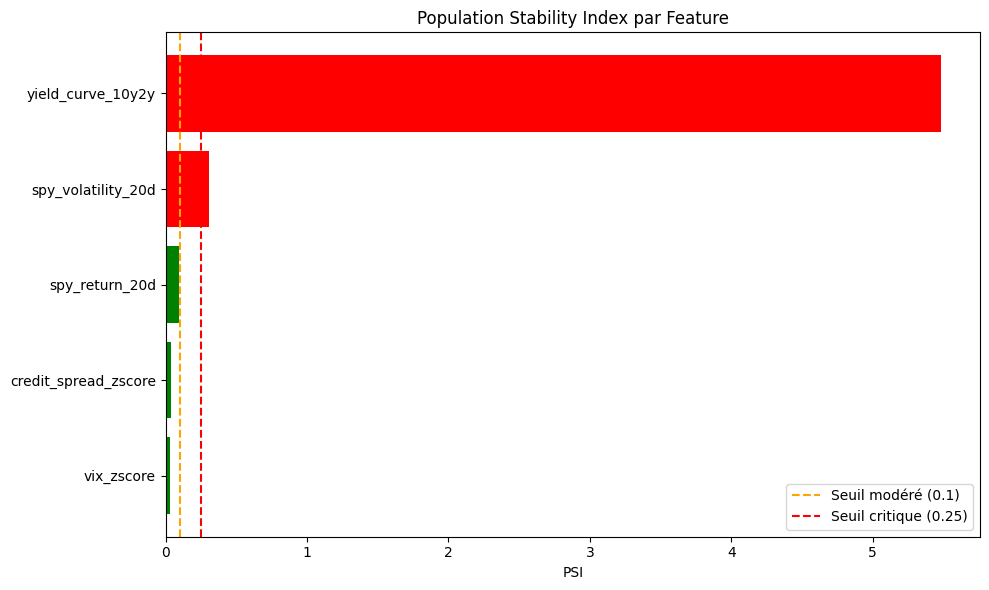

In [4]:
# Visualiser le PSI
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if psi < 0.1 else 'orange' if psi < 0.25 else 'red' for psi in psi_df['psi']]
ax.barh(psi_df['feature'], psi_df['psi'], color=colors)

# Lignes de seuil
ax.axvline(x=0.1, color='orange', linestyle='--', label='Seuil modéré (0.1)')
ax.axvline(x=0.25, color='red', linestyle='--', label='Seuil critique (0.25)')

ax.set_xlabel('PSI')
ax.set_title('Population Stability Index par Feature')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Détection de drift multi-features

On utilise à la fois le PSI et le test de Kolmogorov-Smirnov pour détecter le drift.

In [5]:
# Détecter le drift
drift_detected, reports = detect_data_drift(
    X_reference, 
    X_current, 
    psi_threshold=0.25,
    ks_alpha=0.05
)

print(f"Drift global détecté: {drift_detected}")
print(f"\nRapports par feature:")
print("-" * 80)

for r in sorted(reports, key=lambda x: x.psi, reverse=True):
    status = "DRIFT" if r.drift_detected else "OK"
    print(f"{r.feature:25s} | PSI={r.psi:6.3f} | KS p={r.ks_pvalue:6.4f} | mean_shift={r.mean_shift:+6.2f} | {status}")

2026-05-15 21:03:02,613 - WARNING - Drift détecté sur credit_spread_zscore: PSI=0.034, KS p-value=0.0136
2026-05-15 21:03:02,620 - WARNING - Drift détecté sur spy_volatility_20d: PSI=0.306, KS p-value=0.0000
2026-05-15 21:03:02,626 - WARNING - Drift détecté sur spy_return_20d: PSI=0.092, KS p-value=0.0000
2026-05-15 21:03:02,645 - WARNING - Drift détecté sur yield_curve_10y2y: PSI=5.486, KS p-value=0.0000
2026-05-15 21:03:02,650 - WARNING - Drift détecté sur vix_zscore: PSI=0.027, KS p-value=0.0250


Drift global détecté: True

Rapports par feature:
--------------------------------------------------------------------------------
yield_curve_10y2y         | PSI= 5.486 | KS p=0.0000 | mean_shift= -1.75 | DRIFT
spy_volatility_20d        | PSI= 0.306 | KS p=0.0000 | mean_shift= +0.19 | DRIFT
spy_return_20d            | PSI= 0.092 | KS p=0.0000 | mean_shift= -0.04 | DRIFT
credit_spread_zscore      | PSI= 0.034 | KS p=0.0136 | mean_shift= +0.06 | DRIFT
vix_zscore                | PSI= 0.027 | KS p=0.0250 | mean_shift= +0.06 | DRIFT


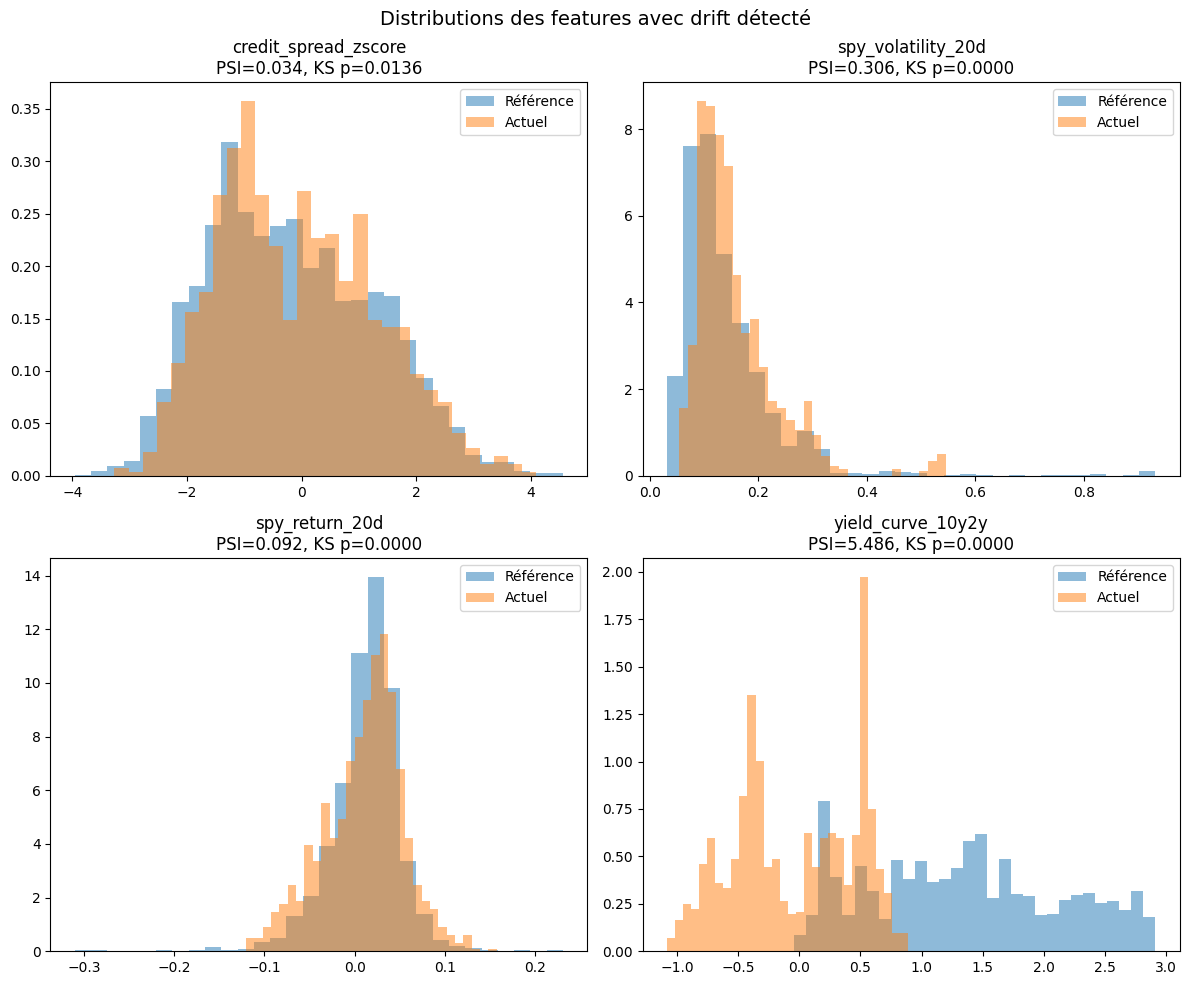

In [6]:
# Visualiser les distributions pour les features avec drift
drift_features = [r.feature for r in reports if r.drift_detected]

if drift_features:
    n_plots = min(len(drift_features), 4)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(drift_features[:n_plots]):
        ax = axes[i]
        
        # Distribution de référence
        ax.hist(X_reference[feature], bins=30, alpha=0.5, label='Référence', density=True)
        # Distribution actuelle
        ax.hist(X_current[feature], bins=30, alpha=0.5, label='Actuel', density=True)
        
        report = [r for r in reports if r.feature == feature][0]
        ax.set_title(f"{feature}\nPSI={report.psi:.3f}, KS p={report.ks_pvalue:.4f}")
        ax.legend()
    
    # Cacher les axes non utilisés
    for i in range(n_plots, 4):
        axes[i].set_visible(False)
    
    plt.suptitle('Distributions des features avec drift détecté', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Aucun drift détecté sur les features.")

## 4. Drift des prédictions

On simule des prédictions pour vérifier si leur distribution a changé.

In [7]:
# Simuler des prédictions (en pratique, on utiliserait le vrai modèle)
# Référence : 60% de prédictions positives
y_ref = np.random.binomial(1, 0.6, 500)

# Cas 1 : Pas de drift
y_current_no_drift = np.random.binomial(1, 0.58, 500)

# Cas 2 : Avec drift
y_current_drift = np.random.binomial(1, 0.35, 500)

# Détecter
drift1, psi1 = detect_prediction_drift(y_ref, y_current_no_drift)
drift2, psi2 = detect_prediction_drift(y_ref, y_current_drift)

print("Prédictions sans drift:")
print(f"  PSI = {psi1:.4f}, Drift = {drift1}")
print(f"  Ratio positifs: ref={y_ref.mean():.2f}, current={y_current_no_drift.mean():.2f}")

print("\nPrédictions avec drift:")
print(f"  PSI = {psi2:.4f}, Drift = {drift2}")
print(f"  Ratio positifs: ref={y_ref.mean():.2f}, current={y_current_drift.mean():.2f}")

Prédictions sans drift:
  PSI = 0.0017, Drift = False
  Ratio positifs: ref=0.59, current=0.61

Prédictions avec drift:
  PSI = 0.1400, Drift = False
  Ratio positifs: ref=0.59, current=0.40


## 5. Monitoring des performances

On vérifie que les métriques du modèle respectent les seuils définis.

In [8]:
# Seuils définis dans la config
print("Seuils de performance configurés:")
for model_type, thresholds in PERFORMANCE_THRESHOLDS.items():
    print(f"\n{model_type}:")
    for key, value in thresholds.items():
        print(f"  {key}: {value}")

Seuils de performance configurés:

regime:
  silhouette_min: 0.15
  stability_min: 0.9

prediction:
  accuracy_min: 0.52
  auc_min: 0.5

backtest:
  sharpe_min: 0.0
  max_drawdown_max: -0.4


In [9]:
# Cas 1 : Métriques OK
metrics_ok = {
    "accuracy": 0.58,
    "auc": 0.62,
    "f1": 0.55,
}

report_ok = check_model_performance(
    metrics_ok, 
    PERFORMANCE_THRESHOLDS['prediction'],
    model_name="deeppilot-rf"
)

print("Cas 1 - Métriques OK:")
print(f"  Alertes: {report_ok.alerts}")
print(f"  Has alerts: {report_ok.has_alerts}")

Cas 1 - Métriques OK:
  Alertes: []
  Has alerts: False


In [10]:
# Cas 2 : Métriques dégradées
metrics_bad = {
    "accuracy": 0.48,  # Sous le seuil de 0.52
    "auc": 0.45,       # Sous le seuil de 0.50
    "f1": 0.40,
}

report_bad = check_model_performance(
    metrics_bad, 
    PERFORMANCE_THRESHOLDS['prediction'],
    model_name="deeppilot-rf"
)

print("Cas 2 - Métriques dégradées:")
print(f"  Has alerts: {report_bad.has_alerts}")
print(f"  Alertes:")
for alert in report_bad.alerts:
    print(f"    - {alert}")

2026-05-15 21:03:03,310 - WARNING - Alertes performance pour deeppilot-rf: ['accuracy: 0.4800 < seuil min 0.5200', 'auc: 0.4500 < seuil min 0.5000']


Cas 2 - Métriques dégradées:
  Has alerts: True
  Alertes:
    - accuracy: 0.4800 < seuil min 0.5200
    - auc: 0.4500 < seuil min 0.5000


In [11]:
# Cas 3 : Backtest avec drawdown excessif
backtest_metrics = {
    "sharpe": 0.45,
    "max_drawdown": -0.42,  # Pire que le seuil de -0.40
    "cagr": 0.06,
}

report_backtest = check_model_performance(
    backtest_metrics,
    PERFORMANCE_THRESHOLDS['backtest'],
    model_name="deeppilot-portfolio"
)

print("Cas 3 - Backtest avec drawdown excessif:")
print(f"  Has alerts: {report_backtest.has_alerts}")
for alert in report_backtest.alerts:
    print(f"    - {alert}")

2026-05-15 21:03:03,319 - WARNING - Alertes performance pour deeppilot-portfolio: ['max_drawdown: -0.4200 < seuil max -0.4000']


Cas 3 - Backtest avec drawdown excessif:
  Has alerts: True
    - max_drawdown: -0.4200 < seuil max -0.4000


## 6. ModelMonitor - Monitoring continu

La classe `ModelMonitor` permet de suivre un modèle en continu avec historique.

In [12]:
# Créer un moniteur
monitor = ModelMonitor(
    model_name="deeppilot-hmm",
    X_reference=X_reference,
    thresholds=PERFORMANCE_THRESHOLDS['regime'],
    psi_threshold=0.25,
    ks_alpha=0.05
)

print(f"Moniteur créé pour: {monitor.model_name}")
print(f"Status initial: {monitor.get_status()}")

2026-05-15 21:03:03,328 - INFO - ModelMonitor initialisé pour deeppilot-hmm


Moniteur créé pour: deeppilot-hmm
Status initial: {'model_name': 'deeppilot-hmm', 'last_drift_check': None, 'drift_detected': False, 'last_performance_check': None, 'has_performance_alerts': False, 'n_checks': 0}


In [13]:
# Simuler plusieurs checks dans le temps
# En production, ceci serait fait périodiquement (cron job, etc.)

print("Simulation de checks périodiques:\n")

# Check 1 : Données normales
drift1, reports1 = monitor.check_data(X_current[:100])
perf1 = monitor.check_performance({"silhouette": 0.22, "stability": 0.95})
print(f"Check 1: drift={drift1}, perf_alerts={perf1.has_alerts}")

# Check 2 : Données normales
drift2, reports2 = monitor.check_data(X_current[100:200])
perf2 = monitor.check_performance({"silhouette": 0.20, "stability": 0.93})
print(f"Check 2: drift={drift2}, perf_alerts={perf2.has_alerts}")

# Check 3 : Performance dégradée
drift3, reports3 = monitor.check_data(X_current[200:300])
perf3 = monitor.check_performance({"silhouette": 0.12, "stability": 0.88})  # Sous les seuils
print(f"Check 3: drift={drift3}, perf_alerts={perf3.has_alerts}")

# Status final
print(f"\nStatus actuel:")
status = monitor.get_status()
for key, value in status.items():
    print(f"  {key}: {value}")

2026-05-15 21:03:03,341 - WARNING - Drift détecté sur credit_spread_zscore: PSI=1.714, KS p-value=0.0000
2026-05-15 21:03:03,344 - WARNING - Drift détecté sur spy_volatility_20d: PSI=4.278, KS p-value=0.0000
2026-05-15 21:03:03,348 - WARNING - Drift détecté sur spy_return_20d: PSI=1.205, KS p-value=0.0000
2026-05-15 21:03:03,351 - WARNING - Drift détecté sur yield_curve_10y2y: PSI=4.948, KS p-value=0.0000
2026-05-15 21:03:03,354 - WARNING - Drift détecté sur vix_zscore: PSI=0.495, KS p-value=0.0000
2026-05-15 21:03:03,358 - WARNING - Drift détecté sur credit_spread_zscore: PSI=0.719, KS p-value=0.0000
2026-05-15 21:03:03,361 - WARNING - Drift détecté sur spy_volatility_20d: PSI=5.952, KS p-value=0.0000
2026-05-15 21:03:03,364 - WARNING - Drift détecté sur spy_return_20d: PSI=1.466, KS p-value=0.0000
2026-05-15 21:03:03,368 - WARNING - Drift détecté sur yield_curve_10y2y: PSI=7.406, KS p-value=0.0000
2026-05-15 21:03:03,370 - WARNING - Drift détecté sur vix_zscore: PSI=1.073, KS p-value

Simulation de checks périodiques:

Check 1: drift=True, perf_alerts=False
Check 2: drift=True, perf_alerts=False
Check 3: drift=True, perf_alerts=True

Status actuel:
  model_name: deeppilot-hmm
  last_drift_check: 2026-05-15T21:03:03.386841
  drift_detected: True
  last_performance_check: 2026-05-15T21:03:03.386841
  has_performance_alerts: True
  n_checks: 3


In [14]:
# Historique des performances
print("\nHistorique des performances:")
for i, report in enumerate(monitor.performance_history):
    print(f"  Check {i+1}: {report.metrics}, alerts={report.alerts}")


Historique des performances:
  Check 1: {'silhouette': 0.22, 'stability': 0.95}, alerts=[]
  Check 2: {'silhouette': 0.2, 'stability': 0.93}, alerts=[]
  Check 3: {'silhouette': 0.12, 'stability': 0.88}, alerts=['silhouette: 0.1200 < seuil min 0.1500', 'stability: 0.8800 < seuil min 0.9000']


## 7. Génération de rapport de monitoring

In [15]:
# Générer un résumé complet
summary = generate_monitoring_summary(
    drift_reports=reports,  # Du check global précédent
    performance_report=report_bad  # Utiliser le rapport avec alertes pour démo
)

print("Résumé du monitoring:")
print("-" * 50)
print(f"Timestamp: {summary['timestamp']}")
print(f"Modèle: {summary['model_name']}")

print(f"\nDrift des données:")
print(f"  Détecté: {summary['data_drift']['detected']}")
print(f"  Features affectées: {summary['data_drift']['features_affected']}/{summary['data_drift']['features_total']}")

print(f"\nPerformances:")
print(f"  Alertes: {summary['performance']['has_alerts']}")
if summary['performance']['alerts']:
    for alert in summary['performance']['alerts']:
        print(f"    - {alert}")

print(f"\nACTION REQUISE: {summary['action_required']}")

Résumé du monitoring:
--------------------------------------------------
Timestamp: 2026-05-15T21:03:03.403775
Modèle: deeppilot-rf

Drift des données:
  Détecté: True
  Features affectées: 5/5

Performances:
  Alertes: True
    - accuracy: 0.4800 < seuil min 0.5200
    - auc: 0.4500 < seuil min 0.5000

ACTION REQUISE: True


## 8. Visualisation du monitoring dans le temps

C:\Users\User\AppData\Local\Temp\ipykernel_9484\1594928234.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2023-01-01', periods=12, freq='M')


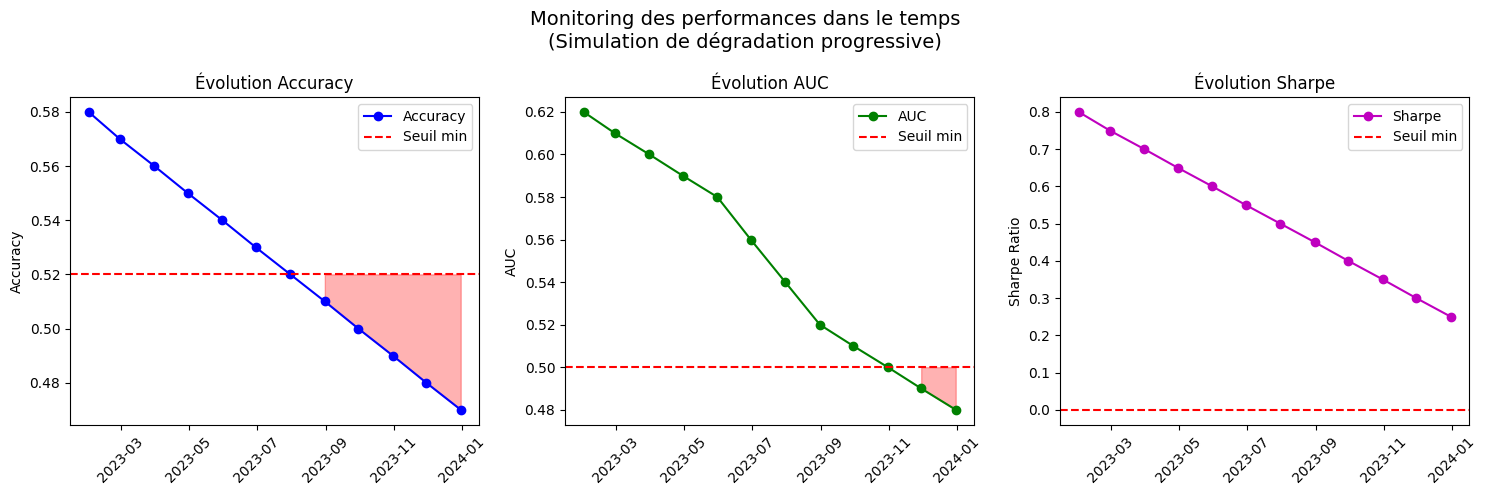

In [16]:
# Simuler l'historique de métriques dans le temps
dates = pd.date_range(start='2023-01-01', periods=12, freq='M')
metrics_history = {
    'date': dates,
    'accuracy': [0.58, 0.57, 0.56, 0.55, 0.54, 0.53, 0.52, 0.51, 0.50, 0.49, 0.48, 0.47],
    'auc': [0.62, 0.61, 0.60, 0.59, 0.58, 0.56, 0.54, 0.52, 0.51, 0.50, 0.49, 0.48],
    'sharpe': [0.8, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30, 0.25],
}
history_df = pd.DataFrame(metrics_history)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy
ax = axes[0]
ax.plot(history_df['date'], history_df['accuracy'], 'b-o', label='Accuracy')
ax.axhline(y=0.52, color='red', linestyle='--', label='Seuil min')
ax.fill_between(history_df['date'], 0.52, history_df['accuracy'].where(history_df['accuracy'] < 0.52), 
                color='red', alpha=0.3)
ax.set_ylabel('Accuracy')
ax.set_title('Évolution Accuracy')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# AUC
ax = axes[1]
ax.plot(history_df['date'], history_df['auc'], 'g-o', label='AUC')
ax.axhline(y=0.50, color='red', linestyle='--', label='Seuil min')
ax.fill_between(history_df['date'], 0.50, history_df['auc'].where(history_df['auc'] < 0.50), 
                color='red', alpha=0.3)
ax.set_ylabel('AUC')
ax.set_title('Évolution AUC')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Sharpe
ax = axes[2]
ax.plot(history_df['date'], history_df['sharpe'], 'm-o', label='Sharpe')
ax.axhline(y=0.0, color='red', linestyle='--', label='Seuil min')
ax.fill_between(history_df['date'], 0, history_df['sharpe'].where(history_df['sharpe'] < 0), 
                color='red', alpha=0.3)
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Évolution Sharpe')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Monitoring des performances dans le temps\n(Simulation de dégradation progressive)', fontsize=14)
plt.tight_layout()
plt.show()

## Résumé

Ce notebook a démontré :

1. **PSI (Population Stability Index)** : mesure de drift par feature
2. **Test de Kolmogorov-Smirnov** : test statistique de changement de distribution
3. **Drift des prédictions** : changement dans la distribution des outputs
4. **Monitoring des performances** : alertes quand métriques sous les seuils
5. **ModelMonitor** : classe pour monitoring continu avec historique

**Actions recommandées quand drift détecté :**
- Investiguer les causes (changement de marché, données manquantes, etc.)
- Réentraîner le modèle sur données récentes
- Ajuster les features si nécessaire
- Mettre à jour les seuils si le contexte a changé

**Compétence C13 validée** : Monitoring des modèles ML